In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import json

In [30]:
df=pd.read_csv("../data/raw.csv")

In [45]:
df.info()

<class 'pandas.DataFrame'>
Index: 298445 entries, 0 to 298449
Data columns (total 32 columns):
 #   Column                        Non-Null Count   Dtype                       
---  ------                        --------------   -----                       
 0   id                            298445 non-null  str                         
 1   latitude                      298445 non-null  float64                     
 2   longitude                     298445 non-null  float64                     
 3   location                      295409 non-null  str                         
 4   vehicle_number                298445 non-null  str                         
 5   vehicle_type                  298445 non-null  str                         
 6   violation_type                298445 non-null  str                         
 7   offence_code                  298445 non-null  str                         
 8   created_datetime              298445 non-null  datetime64[us, Asia/Kolkata]
 9   modified_

In [32]:
df.drop(columns=['description','action_taken_timestamp','closed_datetime'],inplace=True)

In [33]:
df['created_datetime'] = pd.to_datetime(df['created_datetime'], errors='coerce')
df['modified_datetime'] = pd.to_datetime(df['modified_datetime'], errors='coerce')

In [34]:
df = df.dropna(subset=['created_datetime','modified_datetime'])

In [35]:
len(df)

298445

In [36]:
df['created_datetime'] = df['created_datetime'].dt.tz_convert('Asia/Kolkata')
df['modified_datetime'] = df['modified_datetime'].dt.tz_convert('Asia/Kolkata')

In [37]:
df['cdt_minute of day'] = (df['created_datetime'].dt.hour * 60) + df['created_datetime'].dt.minute
df['cdt_hour'] = df['created_datetime'].dt.hour
df['cdt_day_of_week'] = df['created_datetime'].dt.day_name()
df['cdt_month'] = df['created_datetime'].dt.month
df['cdt_date'] = df['created_datetime'].dt.date

In [38]:
df['mdt_minute of day'] = (df['modified_datetime'].dt.hour * 60) + df['modified_datetime'].dt.minute
df['mdt_hour'] = df['modified_datetime'].dt.hour
df['mdt_day_of_week'] = df['modified_datetime'].dt.day_name()
df['mdt_month'] = df['modified_datetime'].dt.month
df['mdt_date'] = df['modified_datetime'].dt.date

In [40]:
df['processing_duration_minutes'] = (df['modified_datetime'] - df['created_datetime']).dt.total_seconds() / 60

In [41]:
df.sample(5)

,id,latitude,longitude,location,vehicle_number,vehicle_type,violation_type,offence_code,created_datetime,modified_datetime,...,cdt_hour,cdt_day_of_week,cdt_month,cdt_date,mdt_minute of day,mdt_hour,mdt_day_of_week,mdt_month,mdt_date,processing_duration_minutes
26355,FKID026355,12.982688,77.607130,"Aruna Chouhan Muduar Road, Tasker Town, Shivaj...",FKN00GL12997,SCOOTER,"[""WRONG PARKING""]",[112],2024-03-30 09:23:46+05:30,2024-03-30 09:29:18.953708+05:30,...,9,Saturday,3,2024-03-30,569,9,Saturday,3,2024-03-30,5.549228
199014,FKID199014,13.011967,77.554469,"80 Feet Ring Road, Orion, Brigade Gateway, Mal...",FKN00GL61591,PASSENGER AUTO,"[""WRONG PARKING""]",[112],2023-12-22 09:45:46+05:30,2023-12-22 09:55:15.500453+05:30,...,9,Friday,12,2023-12-22,595,9,Friday,12,2023-12-22,9.491674
213798,FKID213798,12.938992,77.696251,"Panathur Main Road, Indiqube Alpha, Reddy Layo...",FKN00GL173709,MINI LORRY,"[""WRONG PARKING""]",[112],2023-12-30 08:17:46+05:30,2023-12-30 15:45:51.913820+05:30,...,8,Saturday,12,2023-12-30,945,15,Saturday,12,2023-12-30,448.098564
274332,FKID274332,12.964889,77.576053,"Police Road, Sri Krishna Rajendra Market, Chic...",FKN00GL216570,SCOOTER,"[""NO PARKING""]",[113],2024-01-31 06:39:46+05:30,2024-01-31 06:46:46.118020+05:30,...,6,Wednesday,1,2024-01-31,406,6,Wednesday,1,2024-01-31,7.001967
253619,FKID253619,12.973547,77.551302,"1st Cross Road, Mallige Thotta, Cholurpalya, B...",FKN00GL202152,SCOOTER,"[""NO PARKING""]",[113],2024-01-19 10:34:46+05:30,2024-01-19 10:44:11.717160+05:30,...,10,Friday,1,2024-01-19,644,10,Friday,1,2024-01-19,9.428619


<Axes: ylabel='processing_duration_minutes'>

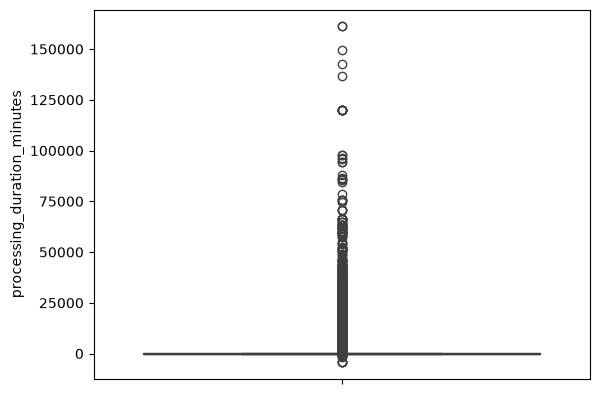

In [42]:
sns.boxplot(df['processing_duration_minutes'])

In [44]:
df['processing_duration_minutes'].describe(percentiles=[0.01, 0.25, 0.50, 0.75, 0.95, 0.99])

count    298445.000000
mean        510.881835
std        2463.155945
min       -4318.555995
1%            0.604041
25%           4.938974
50%          15.896755
75%          71.166056
95%        2688.044205
99%        9367.570118
max      161183.000694
Name: processing_duration_minutes, dtype: float64

In [47]:
OUT_DIR = "data"

PARKING_TYPES = {
    "NO PARKING", "WRONG PARKING", "DOUBLE PARKING", "PARKING IN A MAIN ROAD",
    "PARKING NEAR BUSTOP/SCHOOL/HOSPITAL ETC", "PARKING NEAR ROAD CROSSING",
    "PARKING NEAR TRAFFIC LIGHT OR ZEBRA CROSS", "PARKING ON FOOTPATH",
    "PARKING OPPOSITE TO ANOTHER PARKED VEHICLE", "PARKING OTHER THAN BUS STOP",
}

VEHICLE_FOOTPRINT_WEIGHT = {
    "SCOOTER": 1.0, "MOTOR CYCLE": 1.0, "MOPED": 1.0,
    "CAR": 2.5, "JEEP": 2.5, "VAN": 2.5, "PASSENGER AUTO": 2.0,
    "GOODS AUTO": 2.0, "TEMPO": 3.0, "LGV": 3.5, "MAXI-CAB": 3.0,
    "PRIVATE BUS": 5.0, "BUS (BMTC/KSRTC)": 5.0, "TOURIST BUS": 5.0,
    "FACTORY BUS": 5.0, "SCHOOL VEHICLE": 5.0, "HGV": 5.5, 
    "LORRY/GOODS VEHICLE": 5.5, "MINI LORRY": 4.0, "TRACTOR": 4.0, 
    "TANKER": 5.5, "OTHERS": 2.0,
}

In [ ]:
def clean_pipeline(dataframe: pd.DataFrame):
    df = dataframe.copy()
    
    # 1. Parse Datetimes
    df["created_datetime"] = pd.to_datetime(df["created_datetime"], errors='coerce')
    df["modified_datetime"] = pd.to_datetime(df["modified_datetime"], errors='coerce')
    df = df.dropna(subset=["created_datetime", "modified_datetime"]).copy()
    df["created_datetime"] = df["created_datetime"].dt.tz_convert("Asia/Kolkata")
    df["modified_datetime"] = df["modified_datetime"].dt.tz_convert("Asia/Kolkata")
    
    # 2. Parse JSON Lists
    def safe_json(x):
        try:
            return json.loads(x)
        except (TypeError, json.JSONDecodeError):
            return []
    df["violation_type_list"] = df["violation_type"].apply(safe_json)
    df["offence_code_list"] = df["offence_code"].apply(safe_json)
    df["n_violations"] = df["violation_type_list"].apply(len)
    df["has_parking_violation"] = df["violation_type_list"].apply(
        lambda lst: any(v in PARKING_TYPES for v in lst)
    )
    df["is_pure_parking"] = df["violation_type_list"].apply(
        lambda lst: len(lst) > 0 and all(v in PARKING_TYPES for v in lst)
    )
    
    # 3. Fix Processing Durations
    df["processing_duration_minutes"] = (df["modified_datetime"] - df["created_datetime"]).dt.total_seconds() / 60.0
    df = df.rename(columns={"processing_duration_minutes": "record_lifecycle_minutes_RAW_UNRELIABLE"})
    raw = df["record_lifecycle_minutes_RAW_UNRELIABLE"]
    p95 = raw.quantile(0.95)
    df["record_lifecycle_minutes_capped_p95"] = raw.clip(lower=0, upper=p95)
    df["record_lifecycle_is_negative_artifact"] = raw < 0
    
    # 4. Clean Categoricals
    df["vehicle_type"] = df["vehicle_type"].str.strip().str.upper()
    df["vehicle_footprint_weight"] = df["vehicle_type"].map(VEHICLE_FOOTPRINT_WEIGHT).fillna(2.0)
    df["junction_name"] = df["junction_name"].fillna("No Junction").str.strip()
    df["has_named_junction"] = df["junction_name"] != "No Junction"
    df["police_station"] = df["police_station"].fillna("UNKNOWN").str.strip()
    df["location"] = df["location"].fillna("UNKNOWN")
    df["data_sent_to_scita"] = df["data_sent_to_scita"].astype(bool)
    df["validation_status"] = df["validation_status"].fillna("not_validated")
    
    # 5. Coordinate Bounding Box Check
    df["coord_in_bengaluru_bbox"] = (
        df["latitude"].between(12.6, 13.3) & df["longitude"].between(77.2, 78.0)
    )
    
    # 6. Time Features
    cdt = df["created_datetime"]
    df["cdt_minute_of_day"] = (cdt.dt.hour * 60) + cdt.dt.minute
    df["cdt_hour"] = cdt.dt.hour
    df["cdt_day_of_week"] = cdt.dt.day_name()
    df["cdt_date"] = cdt.dt.date
    df["cdt_month"] = cdt.dt.month
    df["cdt_is_weekend"] = cdt.dt.dayofweek >= 5
    df["cdt_time_bucket"] = pd.cut(
        df["cdt_hour"],
        bins=[-1, 5, 9, 12, 16, 19, 22, 24],
        labels=["late_night", "morning_peak", "late_morning",
                "afternoon", "evening_peak", "night", "late_night2"],
    )
    
    # 7. Deduplicate
    df = df.drop_duplicates(subset="id", keep="first")
    df = df.dropna(subset=["latitude", "longitude"])
    return df